In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import mannwhitneyu

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'figure.titlesize': 7,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [2]:
# Load datasets
ortholog_df = pd.read_csv("./data/human.ortholog_mouse_monkey.dnds_similarity.tsv", sep="\t")
mut_info_df = pd.read_csv('data/human.gencodeV44.pc_canonical.mut_info.tsv', sep='\t')

# Process mutation density (filter for CDS, length > 50, and SNV)
mut_density_map = mut_info_df[
    (mut_info_df['region'] == 'CDS') & 
    (mut_info_df['non-nan length'] > 50) & 
    (mut_info_df['bigwig name'] == 'allsite_snv')
].copy()

# Strip transcript version from gene ID
mut_density_map['gene_id_short'] = mut_density_map['gene id'].str.split('.').str[0]
density_dict = mut_density_map.set_index('gene_id_short')['mean value'].to_dict()

# Prepare plotting dataframe for mouse species
df_plot = ortholog_df[ortholog_df["species"] == "mouse"].copy()

RDHGs vs RIHGs similarity p-value: 1.59e-01
RDHGs vs Other genes similarity p-value: 1.19e-25
RDHGs vs RIHGs mutation density p-value: 2.81e-07
RDHGs vs Other genes mutation density p-value: 2.14e-26


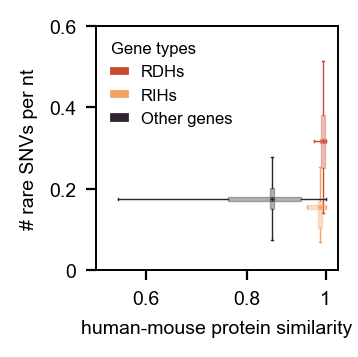

In [3]:
# Get mutation density
human_gene_mut_density_transcript = mut_density_map.set_index('gene id')['mean value'].to_dict()
human_gene_mut_density_transcript = {k.split('.')[0]: v for k, v in human_gene_mut_density_transcript.items()}

dfm = df_plot[df_plot["species"] == "mouse"].copy()
# similarity transform
dfm["similarity"] = dfm["similarity"].apply(lambda x: np.log2(x))
dfm["mutation density"] = dfm['Human'].apply(lambda x: human_gene_mut_density_transcript.get(x, None))
fig, ax = plt.subplots(1, 1, figsize=(1.8, 1.8))

# Define gene type palette
palette = {
    'RDHGs': '#CA4A2E',
    'RIHGs': '#F4A261',
    'Other genes': '#302331'
}
gene_record = {}

# Plot boxplots for each gene type
for gene, color in palette.items():
    sub_df = dfm[dfm["GeneType"] == gene]
    if sub_df.empty:
        continue

    similarity = sub_df["similarity"]
    density = sub_df["mutation density"]

    similarity_median = similarity.median()
    density_median = density.median()
    # Plot boxplots at median positions
    ax.boxplot(
        x=similarity.dropna(),
        vert=False,
        positions=[density_median],
        widths=0.01,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(
            facecolor=color, alpha=0.35, edgecolor=color,
            linewidth=0.5
        ),
        medianprops=dict(color=color, linewidth=0.5),
        whiskerprops=dict(color=color, linewidth=0.5),
        capprops=dict(color=color, linewidth=0.5)
    )
    ax.boxplot(
        density.dropna(),
        vert=True,
        positions=[similarity_median],
        widths=0.015,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(
            facecolor=color, alpha=0.35, edgecolor=color,
            linewidth=0.5
        ),
        medianprops=dict(color=color, linewidth=0.5),
        whiskerprops=dict(color=color, linewidth=0.5),
        capprops=dict(color=color, linewidth=0.5)
    )

    gene_record[gene] = {
        "similarity_median": similarity_median,
        "density_median": density_median
    }

# Set axis limits and ticks
max_y_use = 0.6
y_tick_count = 4
ax.set_ylim(0, max_y_use)
ax.set_yticks(np.linspace(0, max_y_use, y_tick_count))
ax.set_yticklabels([f'{i:g}' for i in np.linspace(0, max_y_use, y_tick_count)])

ax.set_xlim(np.log2(0.52), 0.05)
original_ticks = np.array([0.6, 0.8, 1])
xticks = np.log2(original_ticks)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x:g}" for x in original_ticks])

# RDHGs vs other genes (similarity)
rdhg_similarity = dfm[dfm["GeneType"] == "RDHGs"]["similarity"].dropna()
for gene in ['RIHGs', 'Other genes']:
    other_similarity = dfm[dfm["GeneType"] == gene]["similarity"].dropna()
    _, p_value = mannwhitneyu(rdhg_similarity, other_similarity, alternative='two-sided')
    print(f"RDHGs vs {gene} similarity p-value: {p_value:.2e}")
# RDHGs vs other genes (density)
rdhg_density = dfm[dfm["GeneType"] == "RDHGs"]["mutation density"].dropna()
for gene in ['RIHGs', 'Other genes']:
    other_density = dfm[dfm["GeneType"] == gene]["mutation density"].dropna()
    _, p_value = mannwhitneyu(rdhg_density, other_density, alternative='two-sided')
    print(f"RDHGs vs {gene} mutation density p-value: {p_value:.2e}")

# Finalize plot
ax.set_xlabel('human-mouse protein similarity')
ax.set_ylabel('# rare SNVs per nt')
ax.legend(
    handles=[
        mpl.patches.Patch(color=palette['RDHGs'], label='RDHs'),
        mpl.patches.Patch(color=palette['RIHGs'], label='RIHs'),
        mpl.patches.Patch(color=palette['Other genes'], label='Other genes')
    ],
    loc='upper left',
    fontsize=6,
    frameon=False,
    handlelength=1,
    handleheight=0.1,
    title='Gene types',
    title_fontsize=6,
    alignment='left',
    # bbox_to_anchor=(0.8, 1)
)
plt.tight_layout()